# Module 5 Ungraded Lab 2: Multiparameter Models

Ungraded labs are designed to give learners an opportunity to apply theoretical material presented in previous videos. This ungraded lab builds on the material presented in Ungraded Lab 1 for Module 5.  Material covered previously is provided here again for completeness. Unlike most previous ungraded labs, the answers to this ungraded lab are given in the code below. Ungraded labs can be completed when assigned or in conjunction with upcoming videos. Answers to ungraded labs will be provided in upcoming videos.

## Problem #1 normal-inverse $\chi^2$

The Hubble data frame contains $3$ columns and $24$ rows. The columns are:

- `Galaxy`: A (factor) label identifying the galaxy.

- `y`: The galaxy's relative velocity in kilometres per second.

- `x`: The galaxy's distance in Mega parsecs. 1 parsec is 3.09e13 km.

For this problem, let's just single out `x`. Suppose that `x` is a vector of realizations from $X_1,...,X_{24} \overset{iid}{\sim} N(\mu, \sigma^2)$. Our goal will be to simulate from a joint posterior distribution over $(\mu, \sigma^2)$ given the data. Here's the data: 

In [1]:
library(LaplacesDemon)
hubble = read.table(url("https://raw.githubusercontent.com/bzaharatos/STAT-5630/main/hubble.txt"), sep = "\t")

n = length(hubble$x); 

#frequentist point estimates
var(hubble$x) 
mean(hubble$x)
#se of mean
var(hubble$x)/n

Warning message:
"package 'LaplacesDemon' was built under R version 4.4.1"


[1] 33.81014

[1] 12.05458

[1] 1.408756

In class, we showed that the joint posterior distribution for $(\mu, \sigma^2)$ is normal-scaled-inverse-$\chi^2$. We also wrote down the conditional distributions for $\mu \, | \, \sigma^2, \mathbf{x}$ and for $\sigma^2 \, | \, \mathbf{x}$. We can use these conditional distributions to sample from the joint posterior distribution:

1 Draw $\sigma^2$ from $\sigma^2 \, | \, \mathbf{x}$

2 Draw $\mu$ from $\mu \, | \, \sigma^2, \mathbf{x}$, where $\sigma^2$ is from step 1.

**Draw $m = 10,000$ samples from the joint posterior. Provide a histogram of the marginal distributions $\mu \, | \, \sigma^2,\mathbf{x}$ and $\sigma^2 \, | \, \mathbf{x}$.**

In [2]:
set.seed(1516)
m = 10000
post = matrix(NA,nrow = m, ncol = 2)
##
for (i in 1:m){
    post[i,2] = 1/rgamma(1,(n-1)/2,(n-1)*var(hubble$x)/2) #posterior of sigma^2 | x; #Also: rinvchisq(1, df = n-1, scale= var(hubble$x)) 
    post[i,1] = rnorm(1,mean(hubble$x),sqrt(post[i,2]/n)) #posterior mu | sigma^2 and x
}
colMeans(post)

[1] 12.04755 36.90093

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


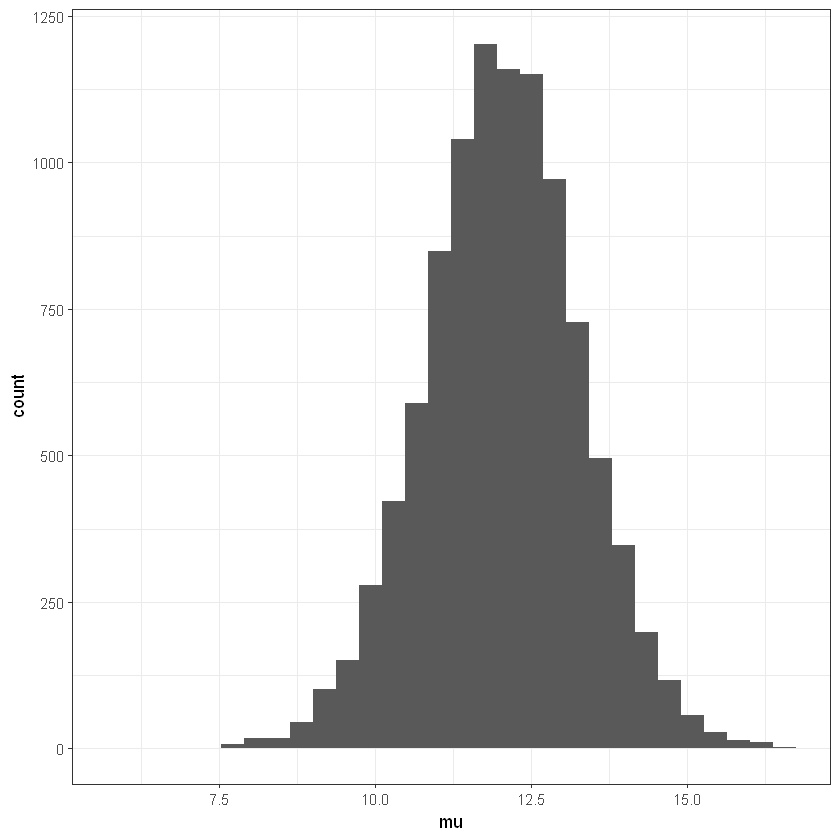

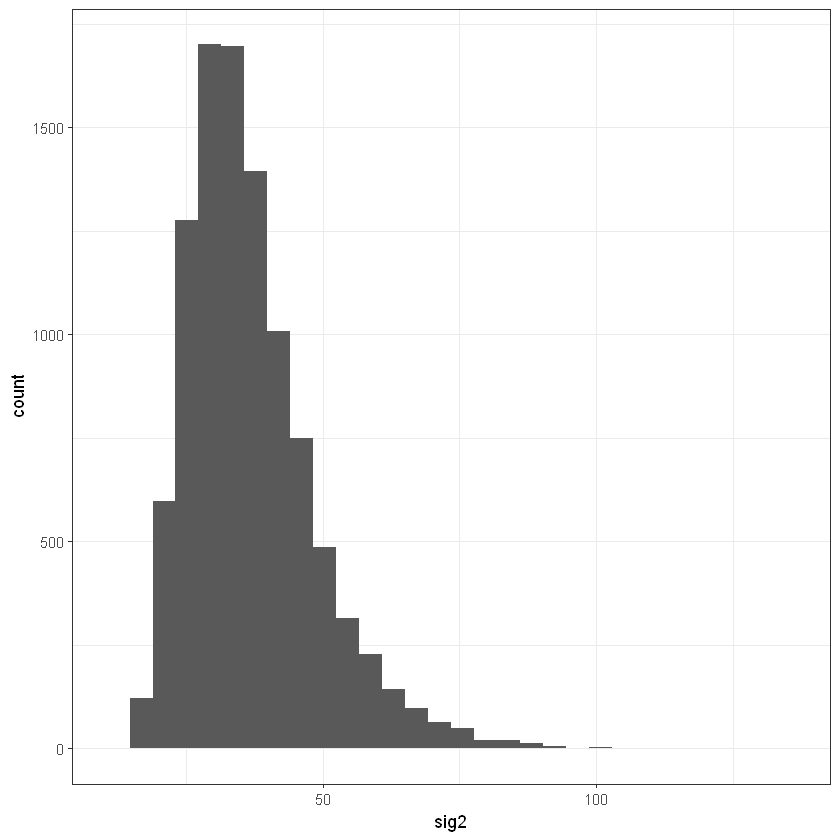

In [3]:
library(ggplot2)

df_plot = data.frame(mu = post[,1], sig2 = post[,2]); 
ggplot(df_plot) + 
    geom_histogram(aes(x = mu)) + 
    theme_bw()

ggplot(df_plot) + 
    geom_histogram(aes(x = sig2)) + 
    theme_bw()

## normal-inverse $\chi^2$ continued...

Now let's assume the more general case, where the priors are not the uninformative priors: 

\begin{align*}
\mu \, | \, \sigma^2 &\sim N(\mu_0, \, \sigma^2\big/k_0) \\
\sigma^2 &\sim \text{inv-}\Gamma\left(\frac{v_0}{2}, \, \frac{v_0\sigma_0^2}{2}\right) \\
\implies (\mu, \sigma^2) &\sim \text{normal-inverse-}\Gamma\left(\mu, \, \sigma^2 \, | \, \mu_0, \, \,\sigma_0^2\big/k_0; v_0, \sigma_0^2\right)
\end{align*}

This implies that 

\begin{align*}
\mu, \sigma^2 \, | \, \mathbf{x} \sim \text{normal-inverse-}\Gamma\left(\mu, \sigma^2 \, | \, \mu_n, \sigma_n^2\big/k_n; v_n, \sigma_n^2\right),
\end{align*}

where \begin{align*} 
k_n &= k_0 + n\\
\mu_n &=  \frac{k_0}{k_n}\mu_0 + \frac{n}{k_n}\bar{x}\\
v_n &= v_0 + n\\
\sigma_n^2 &= \frac{v_0\sigma_0^2 + (n-1)S^2 + \frac{k_0n}{k_n}(\bar{x} - \mu_0)^2}{v_n}
\end{align*}

**First, plot the conditional prior and conditional posterior densities for $\mu \, | \, \sigma^2, \mathbf{x}$ and $\sigma^2 \, | \, \mathbf{x}$, where the prior parameters are given as $k_0 = 1$, $v_0 = 1$, $\sigma_0^2 = 20$, and $\mu_0 = 20$ (again, using the `hubble` data in the posterior). Then, simulate from these conditional distributions. Produce a histogram from the simulation and overlay the corresponding posterior densities.** 

In [4]:
#conditional densities
#prior
k0 = 1; v0 =1; sig02 = 20; mu0 = 20

mu_grid = seq(-25,50,length.out = 1000)
prior_mu = dnorm(mu_grid, mu0, sqrt(sig02/k0))
sig2_grid = seq(0,80,length.out = 1000)
prior_sig2 = dinvgamma(sig2_grid, v0/2, v0*sig02/2)
#dgamma(1/sig2_grid,v0/2, v0*sig02/2)*1/sig2_grid^2


#posterior
kn = k0+n; vn = v0 + n
xbar = mean(hubble$x); s2 = var(hubble$x)
mu_n = k0/kn*mu0 + n/kn*xbar
sign2 = (v0*sig02 + (n-1)*s2 + k0*n/kn*(xbar-mu0)^2)/vn

posterior_sig2 = dinvgamma(sig2_grid, vn/2, vn*sign2/2)
posterior_mu = dnorm(mu_grid, mu_n, sqrt(sign2/kn))

#MAP
#map_mu = mu_grid[which.max(posterior_mu)]
#map_sig2 = sig2_grid[which.max(posterior_sig2)]

#means
cat("The posterior mean for mu is", mu_n,". ")
cat("The posterior mean for sig2 is", (vn*sign2/2)/(vn/2 - 1), ".")


The posterior mean for mu is 12.3724 . The posterior mean for sig2 is 37.31468 .

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


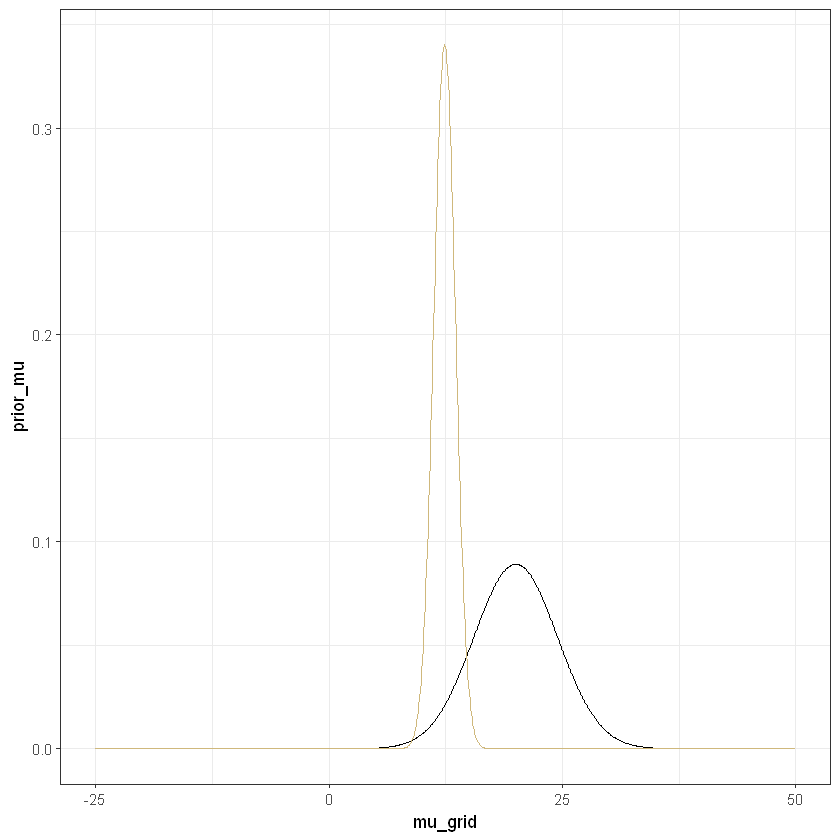

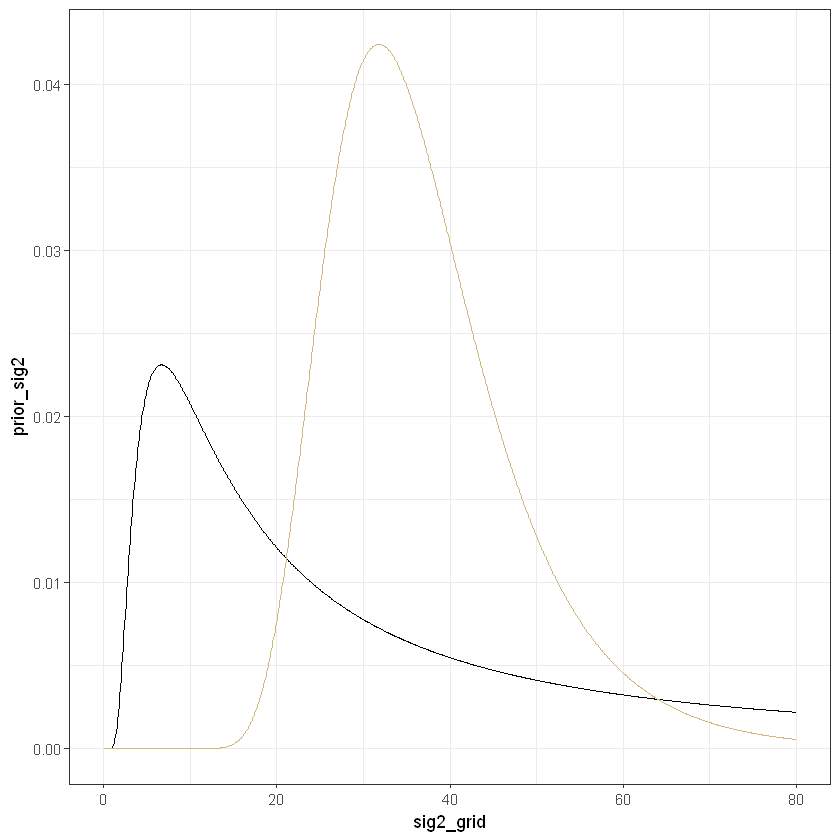

In [5]:
#plotting
df_plot2 = data.frame(mu_grid, prior_mu, posterior_mu, 
                      sig2_grid, prior_sig2, posterior_sig2)
ggplot(df_plot2) +
    geom_line(aes(x = mu_grid, y = prior_mu)) + 
    geom_line(aes(x = mu_grid, y = posterior_mu), col = "#CFB87C") + 
    theme_bw()

ggplot(df_plot2) +
    geom_line(aes(x = sig2_grid, y = prior_sig2)) + 
    geom_line(aes(x = sig2_grid, y = posterior_sig2), col = "#CFB87C") + 
    theme_bw()


In [6]:
set.seed(1516)
m = 10000
post = matrix(NA,nrow = m, ncol = 2)
##
for (i in 1:m){
    post[i,2] = 1/rgamma(1,vn/2,vn*sign2/2) #posterior of sigma^2 | x; #Also: rinvchisq(1, df = n-1, scale= var(hubble$x)) 
    post[i,1] = rnorm(1,mu_n,sqrt(post[i,2]/n)) #posterior mu | sigma^2 and x
}
colMeans(post)
c(mu_n, (vn*sign2/2)/(vn/2 - 1))

[1] 12.36477 37.18526

[1] 12.37240 37.31468

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range
(`geom_line()`)."


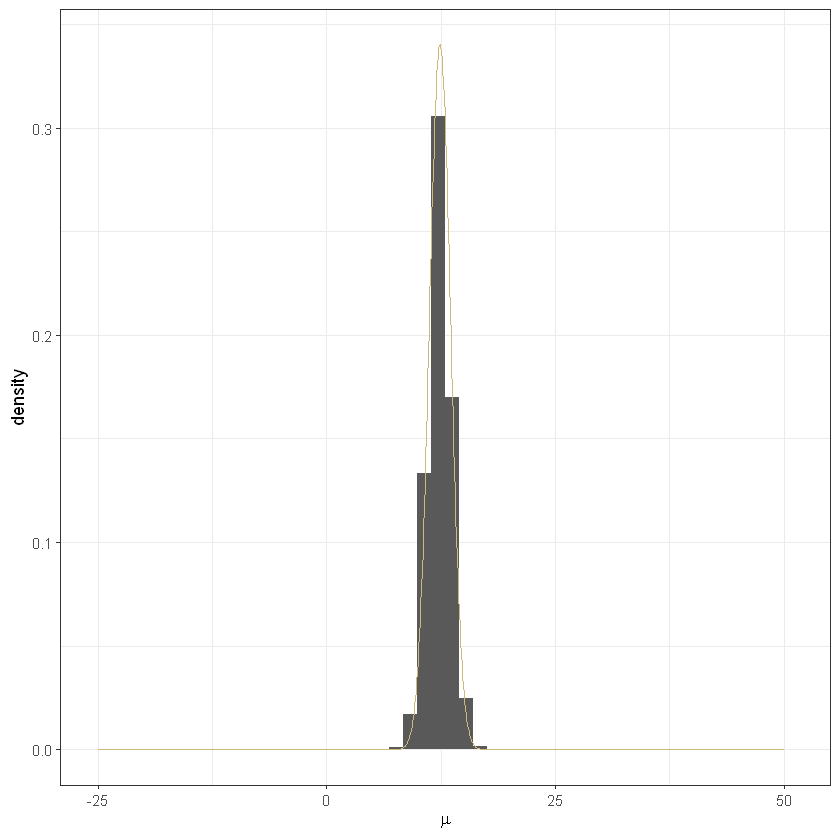

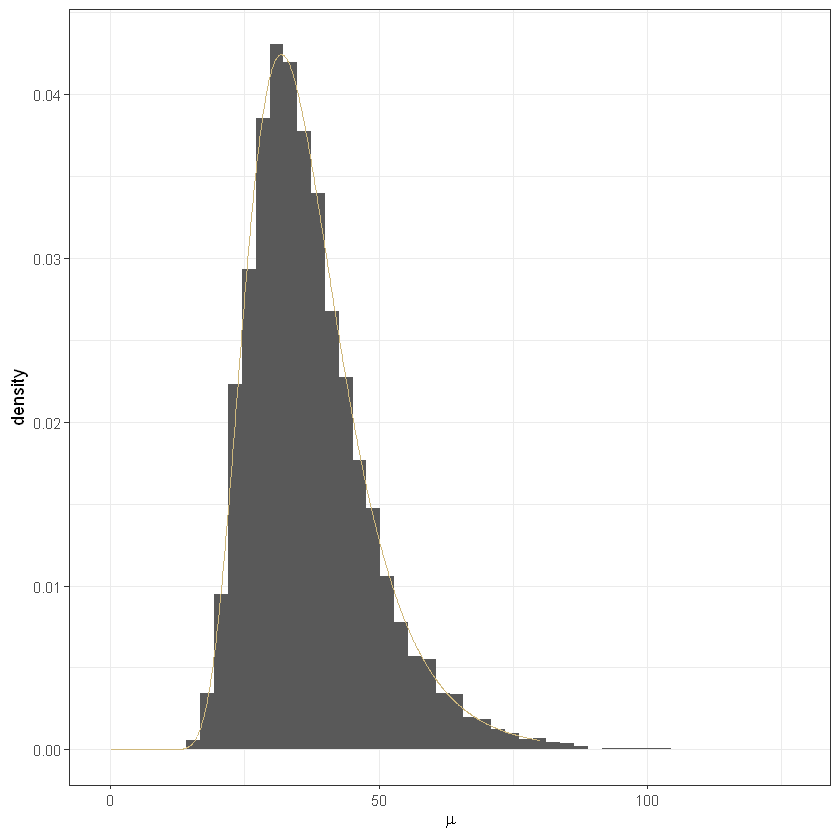

In [7]:
df_compare = data.frame(mu_grid, prior_mu, posterior_mu, 
                      sig2_grid, prior_sig2, posterior_sig2, post)

ggplot(df_compare) + 
    geom_histogram(aes(x = post[,1], y = ..density..), bins = 50, ) + 
    xlab(expression(mu)) +
    geom_line(aes(x = mu_grid, y = posterior_mu), col = "#CFB87C") +
    theme_bw()

ggplot(df_compare) + 
    geom_histogram(aes(x = post[,2], y = ..density..), bins = 50, ) + 
    xlab(expression(mu)) +
    geom_line(aes(x = sig2_grid, y = posterior_sig2), col = "#CFB87C") +
    theme_bw()